In [2]:
!pip install numpy
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 36.1 MB/s  0:00:00 eta 0:00:0136m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 29.3 MB/s  0:00:008.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 41.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 44.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ourpy]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def estimation_ruine(mu,T,beta,u,theta,n) :
    nb_ruine=0
    p=(1+theta)*mu*1/beta
    for i in range (n) :
        
        Nt=np.random.poisson(mu*T,1)[0]
        temps_arrivee=np.random.uniform(0,T,Nt)
        temps_arrivee=np.sort(temps_arrivee)
        #print(Nt)
        #print(temps_arrivee)
        Y=np.random.exponential(1/beta,Nt)
        #print(Y)
        sinistres=np.cumsum(Y)
        #print(sinistres)
        for j in range(Nt):
            if u+p*temps_arrivee[j]-sinistres[j]<=0 :
                nb_ruine+=1
                break
    return nb_ruine/n

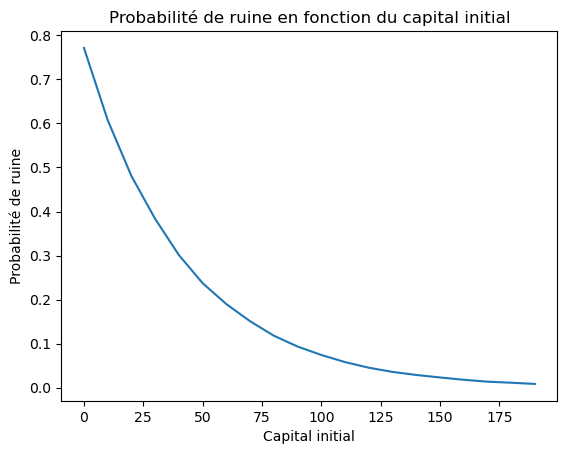

In [4]:
mu=1
T=100
beta=0.1
theta=0.3
n=100000
proba_ruine=np.zeros(20)
u=np.zeros(20)
for k in range(20):
    u[k]=10*k
    proba_ruine[k]=estimation_ruine(mu,T,beta,u[k],theta,n)

plt.plot(u,proba_ruine)
plt.title("Probabilité de ruine en fonction du capital initial")
plt.xlabel("Capital initial")
plt.ylabel("Probabilité de ruine")
plt.show()

-0.028231228739018187


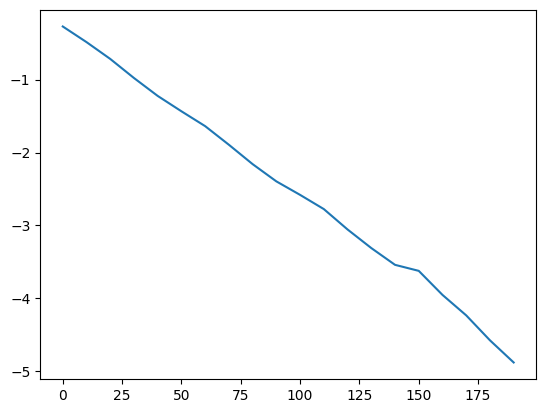

In [68]:
log_proba_ruine=np.log(proba_ruine)
plt.plot(u,log_proba_ruine)

kappa=np.mean(log_proba_ruine[1:20]/u[1:20])
print(kappa)

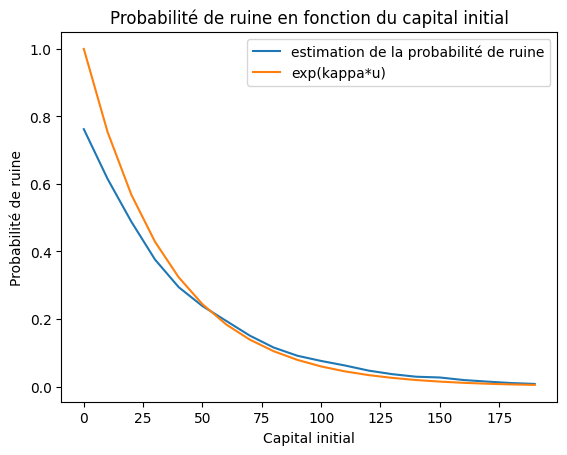

In [70]:
plt.plot(u,proba_ruine,label="estimation de la probabilité de ruine")
plt.plot(u,np.exp(kappa*u),label="exp(kappa*u)")
plt.title("Probabilité de ruine en fonction du capital initial")
plt.xlabel("Capital initial")
plt.ylabel("Probabilité de ruine")
plt.legend()
plt.show()

2ème partie : modèle discounted

In [4]:
def simulation_discounted(mu,T,beta,u,n,theta,rho):
    p=(1+theta)*mu*1/beta
    Nt=np.random.poisson(mu*T,1)[0]
    temps_arrivee=np.random.uniform(0,T,Nt)
    temps_arrivee=np.sort(temps_arrivee)
    Y=np.random.exponential(1/beta,Nt)
    t=np.arange(0,T,n)
    exp=np.exp(rho*temps_arrivee)
    coefs_somme=np.array(Y)*np.array(exp)
    sinistres=np.cumsum(coefs_somme)
    Rt=u+p*t-np.exp(-rho*t)*sinistres[]

SyntaxError: invalid syntax (3250928306.py, line 11)

In [11]:
def p_min_discounted(mu,rho,u):
    return max((u*rho-mu)/(1-np.log(mu/rho)),mu)

In [16]:
def estimation_ruine_discounted(mu,T,beta,u,theta,n,rho) :
    nb_ruine=0
    p=(1+theta)*mu*1/beta
    for i in range (n) :
        
        Nt=np.random.poisson(mu*T,1)[0]
        temps_arrivee=np.random.uniform(0,T,Nt)
        temps_arrivee=np.sort(temps_arrivee)
        Y=np.random.exponential(1/beta,Nt)
        exp=np.exp(rho*temps_arrivee)
        coefs_somme=np.array(Y)*np.array(exp)
        sinistres=np.cumsum(coefs_somme)
        #print(sinistres)
        for j in range(Nt):
            if u+p*temps_arrivee[j]-np.exp(-rho*temps_arrivee[j])*sinistres[j]<=0 :
                nb_ruine+=1
                break
    return nb_ruine/n

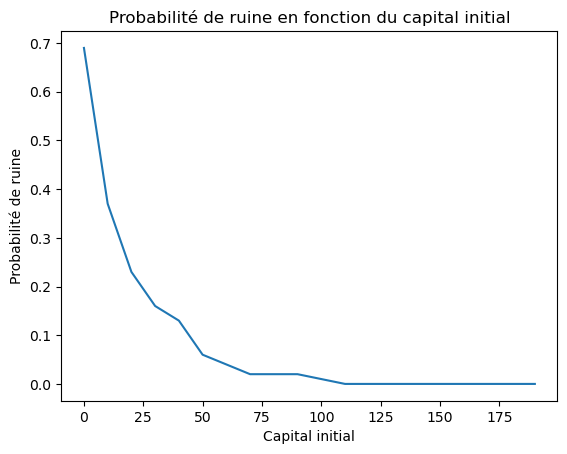

In [17]:
mu=1
T=100
beta=0.1
theta=0.3
n=100
rho=0.1
proba_ruine_discounted=np.zeros(20)
u=np.zeros(20)
for k in range(20):
    u[k]=10*k
    proba_ruine_discounted[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho)

plt.plot(u,proba_ruine_discounted)
plt.title("Probabilité de ruine en fonction du capital initial")
plt.xlabel("Capital initial")
plt.ylabel("Probabilité de ruine")
plt.show()

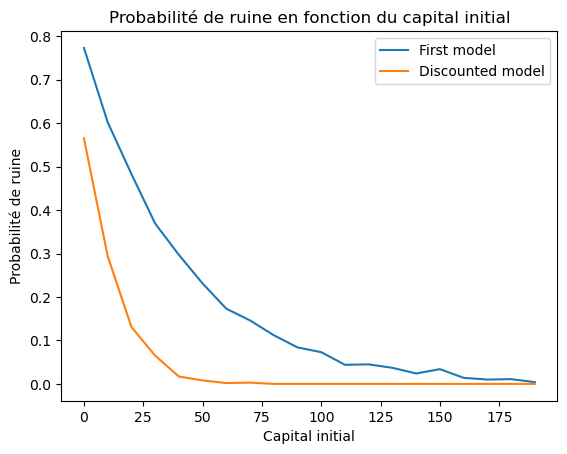

In [19]:
mu=1
T=100
beta=0.1
theta=0.3
n=1000
rho=2
proba_ruine=np.zeros(20)
proba_ruine_discounted=np.zeros(20)
u=np.zeros(20)
for k in range(20):
    u[k]=10*k
    proba_ruine[k]=estimation_ruine(mu,T,beta,u[k],theta,n)
    proba_ruine_discounted[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho)

plt.plot(u,proba_ruine,label='First model')
plt.plot(u,proba_ruine_discounted,label='Discounted model')
plt.title("Probabilité de ruine en fonction du capital initial")
plt.xlabel("Capital initial")
plt.ylabel("Probabilité de ruine")
plt.legend()
plt.show()

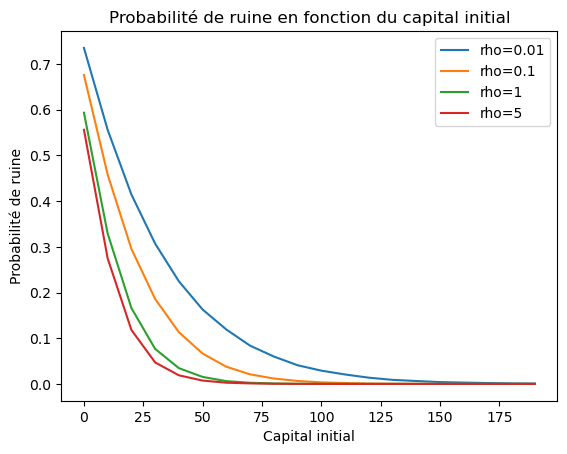

In [27]:
mu=1
T=100
beta=0.1
theta=0.3
n=100000
proba_ruine_1=np.zeros(20)
proba_ruine_2=np.zeros(20)
proba_ruine_3=np.zeros(20)
proba_ruine_4=np.zeros(20)
u=np.zeros(20)
for k in range(20):
    u[k]=10*k
    proba_ruine_1[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho=0.01)
    proba_ruine_2[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho=0.1)
    proba_ruine_3[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho=1)
    proba_ruine_4[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho=5)
    

plt.plot(u,proba_ruine_1,label='rho=0.01')
plt.plot(u,proba_ruine_2,label='rho=0.1')
plt.plot(u,proba_ruine_3,label='rho=1')
plt.plot(u,proba_ruine_4,label='rho=5')
plt.title("Probabilité de ruine en fonction du capital initial")
plt.xlabel("Capital initial")
plt.ylabel("Probabilité de ruine")
plt.legend()
plt.show()